<a href="https://www.kaggle.com/code/minseo14/chess-ai-implementation-of-alphazero-chess?scriptVersionId=303390398" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Implementation of AlphaZero Chess from Google DeepMind 
> Using Reinforcement Learning (RL) with Monte Carlo Tree Search (MCTS) for self-play
> 
> https://www.chess.com/terms/alphazero-chess-engine
> 
> [Mastering Chess and Shogi by Self-Play with a General Reinforcement Learning Algorithm](https://arxiv.org/abs/1712.01815)

## AlphaGo Zero: Learning from Scratch

Building upon the experience with *AlphaGo*, a DeepMind team developed ***AlphaGo Zero*** (Silver et al. 2017a).

**Key Differences from AlphaGo:**

*   **No Human Data:** In contrast to AlphaGo, this program used **no human data or guidance** beyond the basic rules of the game (hence the *Zero* in its name). It learned exclusively from *self-play reinforcement learning*.
*   **Raw Input:** Input consisted of "raw" descriptions of the placements of stones on the Go board.
*   **Learning Method:** Implemented a form of *policy iteration*, interleaving policy evaluation with policy improvement.
*   **MCTS During Learning:** Used *MCTS* to select moves throughout self-play reinforcement learning (unlike AlphaGo, which used MCTS only for live play *after* learning).
*   **Single Network:** Used only *one* deep convolutional ANN.
*   **Simpler MCTS:** Used a simpler version of MCTS.

### AlphaGo Zero's MCTS

*   **No Rollouts:** Did *not* include rollouts of complete games and therefore did not need a rollout policy.
*   **Leaf Node Termination:** Each MCTS simulation ended at a *leaf node* of the current search tree, not at a terminal game position.
*   **Network Guided:** Each MCTS iteration was guided by the output of the deep convolutional network (`f✓`).
*   **Network Input/Output:**
    *   **Input:** Raw board positions.
    *   **Output (Two Parts):**
        1.  **Value (`v`):** A scalar estimate of the probability that the current player will win.
        2.  **Policy (`p`):** A vector of move probabilities for all possible moves (stone placements + pass/resign).

### MCTS as Policy Improvement

Instead of selecting self-play actions directly according to the network's policy `p`, AlphaGo Zero used these probabilities (`p`) and the value (`v`) to direct the MCTS execution. MCTS then returned *new* move probabilities (`π`).

*   These MCTS-derived policies (`π`) benefitted from the numerous simulations run during the search.
*   The result was that the policy actually followed by AlphaGo Zero was an *improvement* over the network's initial policy (`p`).
*   Silver et al. (2017a) stated: "*MCTS may therefore be viewed as a powerful policy improvement operator.*"


# Download Source Code & Install Libraries

In [1]:
!git clone --quiet https://github.com/star14ms/Chess_AI

In [2]:
# !rm -r Chess_AI

In [3]:
!pip install -q hydra-core chess cairosvg 

# Run this code as well when using TPU
# !pip uninstall -q -y tensorflow && pip install -q tensorflow-cpu gymnasium[other] torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 85.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.5 MB/s eta 0:00:00


In [4]:
# import multiprocessing
# print(multiprocessing.cpu_count())

# Chess Environment

/usr/local/lib/python3.11/dist-packages/moviepy/config_defaults.py:1: DeprecationWarning: invalid escape sequence '\P'
  """


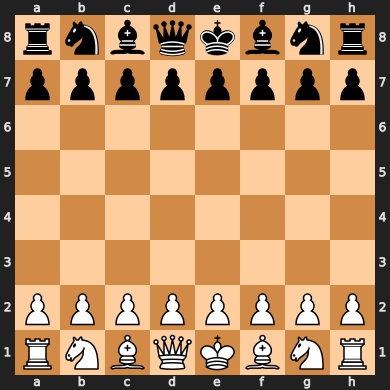

In [5]:
import sys
sys.path.append("./Chess_AI")

import gymnasium as gym
import chess_gym

env = gym.make("Chess-v0")
env.reset()
board = env.action_space.board

display(board)

In [6]:
# import gymnasium as gym
# from utils.policy_human import sample_action_v2
# from utils.visualize import board_to_svg, display_svgs_horizontally
# from IPython.display import SVG

# env = gym.make("Chess-v0", render_mode='rgb_array', show_possible_actions=False, use_4672_action_space=True)
# env.reset()
# board = env.action_space.board

# terminated = False
# truncated = False
# last_svg_str = None # To store the SVG from the previous step
# step_count = 0

# # Display initial board state
# initial_svg = board_to_svg(board, size=250)
# display(SVG(initial_svg))
# last_svg_str = None # Store the first SVG
# last_log_str = '' # Store the first log

# print("Starting Game...")

# while not terminated and not truncated:
#   action, policy_id, policy_title = sample_action(board, return_id=True, return_info=True) # Get action and policy info

#   move = board.action_id_to_move(action)
#   if move:
#       last_log_str += f"Step {step_count + 1}: Action {action} ({board.san(move)})\n"
#   else:
#       last_log_str += f"Step {step_count + 1}: Action {action} (Invalid Move)\n"

#   observation, reward, terminated, truncated, info = env.step(action)
#   step_count += 1

#   current_svg_str = board_to_svg(board, size=250)

#   # Display pairs of boards
#   if last_svg_str: # If we have a stored SVG from the previous step
#       print("Displaying boards from previous and current step:")
#       display_svgs_horizontally([last_svg_str, current_svg_str])
#       print(last_log_str)
#       last_svg_str = None # Clear the stored SVG
#       last_log_str = ''
#   else: # If it's an odd step number (1st, 3rd, etc.), store the current SVG
#       last_svg_str = current_svg_str
# else:
#   if last_svg_str:
#     print("Displaying final board state:")
#     display(SVG(last_svg_str))
#     print(last_log_str)

# # --- After the loop ---
# # Print game result
# if terminated or truncated: # Check why the loop ended
#     if reward == 1:
#       print("White wins!")
#     elif reward == -1:
#       print("Black wins!")
#     elif board.is_stalemate():
#         print("It's a stalemate!")
#     elif board.is_insufficient_material():
#          print("It's a draw due to insufficient material!")
#     elif board.can_claim_draw():
#          print("It's a draw by repetition or 50-move rule!")
#     elif truncated:
#          print("Game truncated.")
#     else:
#          print("Game ended in a draw (other reason).")

# env.close()


In [7]:
# from utils.visualize import draw_possible_actions_on_board

# env.reset()
# board = env.action_space.board
# print(board.legal_actions)
# display(draw_possible_actions_on_board(board))

In [8]:
# from chess import square_name, BLACK
# from IPython.display import display

# env = gym.make("Chess-v0")
# options = {
#     'fen': "k7/8/8/8/8/8/7p/K7 w KQkq - 0 1",
#     # 'fen': "4k2r/8/8/8/8/8/7p/4K3 w KQkq - 0 1",
#     'turn': BLACK
# }
# env.reset(options=options)
# board = env.action_space.board

# action = env.action_space.sample(return_id=True)
# move = env.action_space._action_to_move(action)

# print(board.legal_moves)
# print(list(map(lambda move: move.uci(), board.legal_moves)))
# print(move)
# print(board.san(move))

# display(board)
# env.step(action)
# board

# Train

In [9]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
import os
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

# Get the number of logical CPU cores on your system
cpu_cores = os.cpu_count()
print(f"Logical CPU cores: {cpu_cores}")

# Check the default for ProcessPoolExecutor
with ProcessPoolExecutor() as pool:
    print(f"ProcessPoolExecutor default max_workers: {pool._max_workers}")

# Check the default for ThreadPoolExecutor
with ThreadPoolExecutor() as pool:
    print(f"ThreadPoolExecutor default max_workers: {pool._max_workers}")

Logical CPU cores: 4
ProcessPoolExecutor default max_workers: 4
ThreadPoolExecutor default max_workers: 8


### Supervised Warmup (to prevent cold-start in RL)

In [11]:
num_residual_layers = 40
residual_blocks_out_channels = str([[256]]*num_residual_layers).replace(' ', '')

!python Chess_AI/train_supervised.py \
  network.initial_conv_block_out_channels=[256] \
  network.num_residual_layers=$num_residual_layers \
  network.residual_blocks_out_channels=$residual_blocks_out_channels \
  supervised.epochs=20 \
  supervised.learning_rate=1e-5 \
  supervised.batch_size=512 \
  supervised.val_batch_size=2048 \
  supervised.logging.no_progress=True \
  supervised.amp=True \
  supervised.max_time=43200 \
  supervised.resume=/kaggle/input/models/minseo14/model/pytorch/256x40/1/model_epoch_2_val_3.4916_acc_58.25.pth \
  supervised.data_paths="[ \
    /kaggle/input/lichess-mate-position/mate_in_1_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/mate_in_2_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/mate_in_3_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/mate_in_4_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/mate_in_5_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/endgame_without_mate_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KQ_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KR_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBB_flipped_expanded.jsonl, \
    /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBN_flipped_expanded.jsonl \
  ]"

Configuration (used hyperparams):

supervised:
  data_paths:
  - /kaggle/input/lichess-mate-position/mate_in_1_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/mate_in_2_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/mate_in_3_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/mate_in_4_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/mate_in_5_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/endgame_without_mate_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KQ_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KR_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBB_flipped_expanded.jsonl
  - /kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBN_flipped_expanded.jsonl
  epochs: 20
  batch_size: 512
  val_batch_size: 2048
  learning_rate: 1.0e-05
  pol

### Reinforcement Learning

In [12]:
# #!/usr/bin/env python3
# """Create kaggle_fen_override.yaml for Kaggle datasets."""

# import yaml

# initial_board_fen = [
#     {"path": "/kaggle/input/lichess-mate-position/mate_in_4_flipped.json", "weight": 0.2, "max_game_moves": 1},
#     {"path": "/kaggle/input/lichess-mate-position/mate_in_5_flipped.json", "weight": 0.2, "max_game_moves": 1},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KQ_flipped.json", "weight": 0.2, "max_game_moves": 1},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KR_flipped.json", "weight": 0.2, "max_game_moves": 1},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBB_flipped.json", "weight": 0.15, "max_game_moves": 1},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBN_flipped.json", "weight": 0.5, "max_game_moves": 1},
# ]

# # Output: list only (for Hydra override: training.initial_board_fen=@config/kaggle_fen_override.yaml)
# output_path = "./kaggle_fen_override.yaml"
# with open(output_path, "w", encoding="utf-8") as f:
#     yaml.dump(initial_board_fen, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

# print(f"Created {output_path}")
# print("\nRun training with:")
# print("  python MCTS/train.py training.initial_board_fen=@config/kaggle_fen_override.yaml")


In [13]:
# num_residual_layers = 40
# residual_blocks_out_channels = str([[128]]*num_residual_layers).replace(' ', '')

# initial_board_fen = [
#     {"path": "/kaggle/input/lichess-mate-position/mate_in_4_flipped.json", "weight": 0.25, "max_game_moves": 10},
#     {"path": "/kaggle/input/lichess-mate-position/mate_in_5_flipped.json", "weight": 0.25, "max_game_moves": 13},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KQ_flipped.json", "weight": 0.15, "max_game_moves": 29},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KR_flipped.json", "weight": 0.15, "max_game_moves": 29},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBB_flipped.json", "weight": 0.15, "max_game_moves": 29},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBN_flipped.json", "weight": 0.05, "max_game_moves": 29},
# ]
# # OmegaConf format: [{path:x,weight:0.2,max_game_moves:10},...]
# fen_override = "[" + ",".join(
#     f"{{path:{e['path']},weight:{e['weight']},max_game_moves:{e['max_game_moves']}}}"
#     for e in initial_board_fen
# ) + "]"

# !python Chess_AI/MCTS/train.py \
#   network.initial_conv_block_out_channels=[128] \
#   network.num_residual_layers=$num_residual_layers \
#   network.residual_blocks_out_channels=$residual_blocks_out_channels \
#   mcts.iterations=2048 \
#   mcts.batch_size=32 \
#   mcts.dirichlet_epsilon=0.25 \
#   training.tpu_learning_rate_multiplier=1.0 \
#   training.num_training_iterations=320 \
#   training.max_training_time_seconds=43200 \
#   training.progress_bar=False \
#   training.batch_size=64 \
#   training.self_play_dtype="float16" \
#   training.inference_server_max_batch_size=1024 \
#   training.self_play_steps_per_epoch=1024 \
#   training.initial_board_fen=$fen_override \
#   training.self_play_workers=128 \
#   training.checkpoint_load="/kaggle/input/models/minseo14/model/pytorch/128x40-v2/3/model-RL-280-m3m4-2048.pth"
#   # network.batch_norm_eps=1e-5 \
#   # training.amp=False \
#   # training.use_inference_server=False \
#   # training.inference_server_logging_enabled=False \

In [14]:
# num_residual_layers = 40
# residual_blocks_out_channels = str([[128]]*num_residual_layers).replace(' ', '')

# initial_board_fen = [
#     {"path": "/kaggle/input/lichess-mate-position/mate_in_4_flipped.json", "weight": 0.2, "max_game_moves": 10},
#     {"path": "/kaggle/input/lichess-mate-position/mate_in_5_flipped.json", "weight": 0.2, "max_game_moves": 13},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KQ_flipped_expanded.jsonl", "weight": 0.2, "max_game_moves": 29},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KR_flipped_expanded.jsonl", "weight": 0.2, "max_game_moves": 29},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBB_flipped_expanded.jsonl", "weight": 0.15, "max_game_moves": 29},
#     {"path": "/kaggle/input/lichess-mate-position/minimal_endgames_trajectories_K_vs_KBN_flipped_expanded.jsonl", "weight": 0.05, "max_game_moves": 29},
# ]
# # OmegaConf format: [{path:x,weight:0.2,max_game_moves:10},...]
# fen_override = "[" + ",".join(
#     f"{{path:{e['path']},weight:{e['weight']},max_game_moves:{e['max_game_moves']}}}"
#     for e in initial_board_fen
# ) + "]"

# !python Chess_AI/MCTS/train.py \
#   network.initial_conv_block_out_channels=[128] \
#   network.num_residual_layers=$num_residual_layers \
#   network.residual_blocks_out_channels=$residual_blocks_out_channels \
#   mcts.iterations=32 \
#   mcts.batch_size=32 \
#   mcts.dirichlet_epsilon=0.25 \
#   training.num_training_iterations=300 \
#   training.max_training_time_seconds=43200 \
#   training.replay_buffer_size=16384 \
#   training.batch_size=64 \
#   training.self_play_workers=4 \
#   training.use_inference_server=True \
#   training.inference_server_logging_enabled=True \
#   training.initial_board_fen=$fen_override \
#   training.checkpoint_load="/kaggle/input/models/minseo14/model/pytorch/128x40-v2/3/model-RL-280-m3m4-2048.pth"
#   # training.progress_bar=True \

# Test

In [15]:
# import sys
# sys.path.append("Chess_AI/MCTS")

# import torch
# from omegaconf import OmegaConf

# from MCTS.training_modules.chess import create_chess_network
# from utils.profile_model import profile_model


# def print_game_result(board, reward, terminated, truncated):
#   # --- After the loop ---
#   # Print game result
#   if terminated or truncated: # Check why the loop ended
#       if board.is_foul():
#         print("Game ended in a foul!")
#       if reward == 1:
#         print("White wins!")
#       elif reward == -1:
#         print("Black wins!")
#       elif board.is_stalemate():
#           print("It's a stalemate!")
#       elif board.is_insufficient_material():
#           print("It's a draw due to insufficient material!")
#       elif board.can_claim_draw():
#           print("It's a draw by repetition or 50-move rule!")
#       elif truncated:
#           print("Game truncated.")
#       else:
#           print("Game ended in a draw (other reason).")


# cfg = OmegaConf.load("Chess_AI/config/train_mcts.yaml")
# # checkpoint_path = cfg.training.get("checkpoint_dir_load", "./model.pth")
# # cfg.network.num_filters=[64]
# # cfg.network.num_residual_layers=32
# # cfg.network.conv_blocks_channel_lists=[[64]]*32
# cfg.network.conv_bias=True

# # Load config directly without hydra decorator
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         checkpoint_path = os.path.join(dirname, filename)

# device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
# print(device)

# # Initialize network with config parameters
# model = create_chess_network(cfg, device)
# print(model)
# # Load the model from checkpoint
# model.load_state_dict(torch.load(checkpoint_path, map_location='cpu')['model_state_dict'])
# print('Model loaded!')
# model.eval()  # Set model to evaluation mode
# model.to(device)

# profile_model(model, board.get_board_vector(history_steps=cfg.env.history_steps))

In [16]:
# from utils.policy_human import sample_action
# from utils.visualize import board_to_svg, display_svgs_horizontally, visualize_policy_on_board, draw_possible_actions_on_board
# from IPython.display import SVG
# from utils.analyze import interpret_action_4672
# from MCTS.training_modules.chess import create_chess_env
# from MCTS.policy import execute_policy_mcts

# env = create_chess_env(cfg, render=False)
# env.reset()
# # env.reset(options={"fen": "r3k2r/8/8/8/8/8/8/R3K2R w - - 0 1"})
# board = env.board

# terminated = False
# truncated = False
# last_svg_str = None # To store the SVG from the previous step
# step_count = 0

# mcts_iterations = 800
# deterministic = False
# image_size = 400

# # Display initial board state
# initial_svg = board_to_svg(board, size=image_size)
# display(SVG(initial_svg))
# last_svg_str = None # Store the first SVG
# last_log_str = '' # Store the first log
# last_policy_probs = None

# print("Starting Game...")

# while not terminated and not truncated:
#   action, policy_probs = execute_policy_mcts(cfg, model, board, device, mcts_iterations=mcts_iterations, deterministic=deterministic) # Get action and policy info

#   if action not in board.legal_actions:
#     action_info = interpret_action_4672(action)
#     if action_info:
#         last_log_str += f"Step {step_count + 1}: Action {action} (Color: {'Black' if board.turn else 'White'}, UCI: {action_info['uci_pattern']}, Move: {action_info['move_type']})\n"
#     else:
#         last_log_str += f"Step {step_count + 1}: Action {action} (Invalid/Unknown Action)\n"
#   else:
#     last_log_str += f"Step {step_count + 1}: Action {action} ({board.action_id_to_move(action)})\n"

#   current_policy_probs = visualize_policy_on_board(board, policy_probs, image_size=image_size)
#   observation, reward, terminated, truncated, info = env.step(action)
#   step_count += 1
#   current_svg_str = board_to_svg(board, size=image_size)

#   # display(draw_possible_actions_on_board(board, draw_action_ids=True))
#   # current_policy_distribution = visualize_policy_distribution(policy_probs.cpu().numpy(), 0, board)

#   # Display pairs of boards
#   if last_svg_str: # If we have a stored SVG from the previous step
#       print("Displaying boards from previous and current step:")
#       display_svgs_horizontally([last_policy_probs, last_svg_str, current_policy_probs, current_svg_str])
#       print(last_log_str)
#       last_svg_str = None # Clear the stored SVG
#       last_log_str = ''
#       last_policy_probs = None
#   else: # If it's an odd step number (1st, 3rd, etc.), store the current SVG
#       last_svg_str = current_svg_str
#       last_policy_probs = current_policy_probs
# else:
#   if last_svg_str:
#     print("Displaying final board state:")
#     display_svgs_horizontally([last_policy_probs, last_svg_str])
#     print(last_log_str)

# print_game_result(board, reward, terminated, truncated)
# env.close()


In [17]:
# # !python Chess_AI/utils/visualize_learning_curves.py "../input/model/pytorch/biased64x32/8/model.pth" "/kaggle/working/"
# !python Chess_AI/utils/visualize_learning_curves.py "/kaggle/working/checkpoints/model.pth" "/kaggle/working/"

In [18]:
# !python Chess_AI/test/test_policy_legality.py \
#     network.conv_bias=True \
#     training.checkpoint_dir_load="../input/model/pytorch/biased64x32/10/model.pth"
#     # training.checkpoint_dir_load="/kaggle/working/checkpoints/model.pth"